# 🚗 Dealership AI Intelligence System

## Project Overview

This project demonstrates how Artificial Intelligence can help a car dealership make better business decisions using data.

The system will analyse used car market data and build machine learning models that assist dealerships with pricing, purchasing decisions, and sales strategy.

Instead of relying on guesswork, dealerships can use AI predictions to maximize profit and reduce risk.

---

## Business Problem

Car dealerships face three common challenges:

1. Determining the correct price for a car.
2. Identifying vehicles that can generate profit.
3. Knowing which cars will sell faster.

Making wrong decisions in these areas can lead to financial losses or slow inventory turnover.

This AI system is designed to solve these problems using data-driven predictions.

---

## AI System Components

The project will build three machine learning models:

### 1. Car Price Prediction Model
Predicts the fair market value of a vehicle based on features such as:
- Year
- Manufacturer
- Model
- Condition
- Mileage
- Fuel type

This helps dealerships avoid overpricing or underpricing vehicles.

---

### 2. Profit Opportunity Detection Model
Identifies vehicles that are likely to generate higher resale profit.

The system compares predicted market price with listing price to detect undervalued cars.

This helps dealerships know **which cars to buy and resell**.

---

### 3. Fast-Selling Vehicle Prediction Model
Predicts which cars are more likely to sell quickly.

This helps dealerships prioritize inventory that will move faster and reduce storage costs.

---

## Technologies Used

The system will be developed using the following tools:

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook

These tools will be used for data analysis, model training, and prediction.

---

## Expected Outcome

By the end of the project we will have:

1. A cleaned and prepared dataset
2. Multiple trained machine learning models
3. A demonstration system capable of making predictions

This project demonstrates how AI can be applied to real-world dealership operations.


# Step 1 — Load and Inspect the Dataset

Before building any AI model, we must first understand the data.

This step focuses on:
- Loading the dataset
- Inspecting the structure
- Understanding available features
- Identifying potential data quality issues

This process is called **Exploratory Data Analysis (EDA)** and it helps us understand what information the dataset contains before cleaning or training models.

Dataset: `vehicles.csv`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("vehicles.csv")


In [3]:
df.shape


(426880, 26)

In [4]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
df.describe()


,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


# Step 2 — Data Cleaning

The dataset contains 26 columns, but many of them are not useful for machine learning.

Examples of columns we will remove:
- id
- url
- region_url
- image_url
- description
- county
- VIN
- lat / long

These columns do not help predict car price or demand.

Our focus will be on **important vehicle features** such as:

- price
- year
- manufacturer
- model
- condition
- fuel
- odometer
- transmission
- drive
- type
- paint_color
- state

Cleaning the dataset improves model performance and prevents errors during training.


In [7]:
cols_to_drop = [
'id','url','region_url','image_url','description','county','VIN','lat','long'
]

df = df.drop(columns=cols_to_drop)

df.head()


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [8]:
df.isnull().sum()


region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
state                0
posting_date        68
dtype: int64

In [9]:
df = df[(df.price > 500) & (df.price < 100000)]


In [10]:
important_cols = [
'year','manufacturer','model','fuel','odometer','transmission','title_status'
]

df = df.dropna(subset=important_cols)


In [11]:
df.shape


(352288, 17)

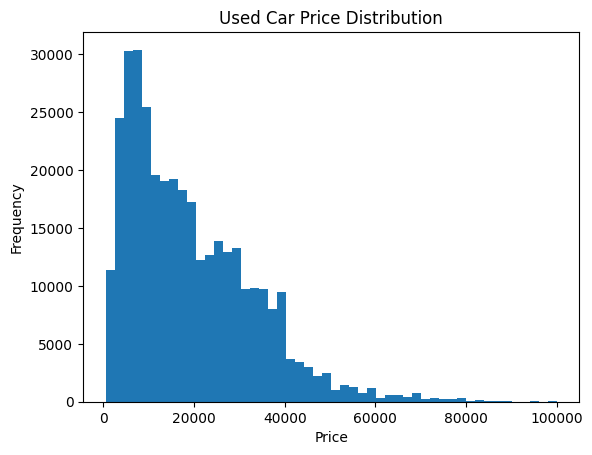

In [12]:
plt.hist(df['price'], bins=50)
plt.title("Used Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# Step 2 — Data Cleaning Strategy

The used car dataset contains missing values in many columns.

Not all columns are useful for our AI system, so we will:

## Columns we WILL keep
These are useful for car pricing and dealership decisions.

- price
- year
- manufacturer
- model
- condition
- fuel
- odometer
- transmission
- drive
- type
- paint_color
- state

These features help predict:

1. Car price (Price Prediction Model)
2. Car demand patterns (Inventory Model)
3. Market trends (Demand Forecast Model)

## Columns we will DROP
These do not help with prediction or dealership strategy.

- id
- url
- region_url
- VIN
- image_url
- description
- county
- lat
- long

## Handling Missing Data

Numeric columns:
- year
- odometer

We will fill them using **median values**.

Categorical columns:
- manufacturer
- model
- fuel
- transmission
- drive
- type
- paint_color
- condition

We will fill them using **most common value (mode)**.

Special Case:
- size column has too many missing values (>80%)
- We will DROP this column.

## After Cleaning
We will have a **stable dataset** ready for:

- Data Analysis
- Feature Engineering
- Machine Learning


In [13]:
# STEP 2 — Clean the Dataset

import numpy as np

# Drop useless columns safely
drop_cols = [
'id','url','region_url','VIN','image_url','description',
'county','lat','long'
]

df = df.drop(columns=drop_cols, errors='ignore')

# Drop column with too many missing values
df = df.drop(columns=['size'], errors='ignore')

# Fill numeric values
df['year'] = df['year'].fillna(df['year'].median())
df['odometer'] = df['odometer'].fillna(df['odometer'].median())

# Fill categorical values
cat_cols = [
'manufacturer','model','condition','fuel',
'transmission','drive','type','paint_color'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop remaining missing rows
df = df.dropna()

# Convert year to integer
df['year'] = df['year'].astype(int)

print(df.shape)
print(df.isnull().sum())


(208404, 16)
region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
posting_date    0
dtype: int64


### STEP 3 — Feature Engineering

Goal: create better signals for machine learning models.

New Features Created:
- **car_age** → how old the vehicle is
- **price_per_age** → depreciation signal
- **log_price** → stabilizes price distribution for ML models

These features help models detect:
- price patterns
- vehicle depreciation
- resale value signals


In [14]:
# STEP 3 — Feature Engineering

import numpy as np

# Create car age
current_year = 2024
df["car_age"] = current_year - df["year"]

# Avoid negative ages (bad data)
df = df[df["car_age"] >= 0]

# Price per age (value indicator)
df["price_per_age"] = df["price"] / (df["car_age"] + 1)

# Log price (helps ML models)
df["log_price"] = np.log1p(df["price"])

# Preview new dataset
print(df.shape)
df.head()


(208404, 19)


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,car_age,price_per_age,log_price
27,auburn,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,4wd,pickup,white,al,2021-05-04T12:31:18-0500,10,3053.636364,10.422013
28,auburn,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,4wd,pickup,blue,al,2021-05-04T12:31:08-0500,14,1506.000000,10.025307
29,auburn,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,4wd,pickup,red,al,2021-05-04T12:31:25-0500,4,7918.000000,10.586357
30,auburn,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,4wd,pickup,red,al,2021-05-04T10:41:31-0500,7,3873.750000,10.341452
31,auburn,15000,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,2021-05-03T14:02:03-0500,11,1250.000000,9.615872


 ### STEP 4 — Preparing Data for Machine Learning

Target variable:
- **price**

Features selected:
- **year**
- **odometer**
- **car_age**

These features help the model learn vehicle depreciation patterns.

Important rule in machine learning:

A feature must **not contain the target variable**.  
Using such features would cause **data leakage**, leading to unrealistic model performance.



In [15]:
# STEP 4 — Prepare ML Dataset (Improved)

# Target variable
y = df["price"]

# Features including vehicle identity
features = [
    "year",
    "odometer",
    "car_age",
    "manufacturer",
    "condition",
    "fuel",
    "transmission",
    "drive",
    "type"
]

X = df[features]

print(X.head())
print(y.head())


    year  odometer  car_age manufacturer  condition fuel transmission drive  \
27  2014   57923.0       10          gmc       good  gas        other   4wd   
28  2010   71229.0       14    chevrolet       good  gas        other   4wd   
29  2020   19160.0        4    chevrolet       good  gas        other   4wd   
30  2017   41124.0        7       toyota       good  gas        other   4wd   
31  2013  128000.0       11         ford  excellent  gas    automatic   rwd   

      type  
27  pickup  
28  pickup  
29  pickup  
30  pickup  
31   truck  
27    33590
28    22590
29    39590
30    30990
31    15000
Name: price, dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder

# ✅ FIX: avoid SettingWithCopyWarning
X = X.copy()

le_dict = {}

categorical_cols = ["manufacturer","condition","fuel","transmission","drive","type"]

for col in categorical_cols:
    le = LabelEncoder()
    X.loc[:, col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

print("Encoded Features (Label Encoding):")
print(X.head())

Encoded Features (Label Encoding):
    year  odometer  car_age manufacturer condition fuel transmission drive  \
27  2014   57923.0       10           14         2    2            2     0   
28  2010   71229.0       14            7         2    2            2     0   
29  2020   19160.0        4            7         2    2            2     0   
30  2017   41124.0        7           38         2    2            2     0   
31  2013  128000.0       11           13         0    2            0     2   

   type  
27    8  
28    8  
29    8  
30    8  
31   10  


## MODEL TRAINING

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(166723, 9) (41681, 9)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[32675.47225329 20518.09399727 30917.97943233 18757.62736725
 14464.13557705]


In [20]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 8463.710579795788


In [21]:
print("Actual prices:", y_test.head().values)
print("Predicted prices:", y_pred[:5])

Actual prices: [30990 21952 23990  6200  6500]
Predicted prices: [32675.47225329 20518.09399727 30917.97943233 18757.62736725
 14464.13557705]


### NOTE: The problem that we have is that the actual price and the predicted price have a huge gap inbetween which makes the model very weak and not helpful. The main reason being the features used. The features used are not enough for the model to be trained at and give better predictions therefore we have to add more features. *MAE: $9616*

In [22]:
features = [
    'year',
    'odometer',
    'car_age',
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type'
]

X = df[features]
y = df['price']

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
print(X.shape)

(208404, 68)


In [25]:
# Save feature columns for Streamlit app
model_columns = X.columns.tolist()

import joblib
joblib.dump(model_columns, "model_columns.pkl")

print("Feature columns saved.")

Feature columns saved.


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("New MAE:", mae)

New MAE: 2410.9703529581097


### NOTE: As you can see the MAE dropped 3 to 4x which realy got, it improved by 75% already.

In [30]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

car_age               0.222072
odometer              0.215093
year                  0.199907
drive_fwd             0.110253
fuel_gas              0.055444
transmission_other    0.014463
type_truck            0.014308
condition_good        0.011337
type_sedan            0.010423
drive_rwd             0.010363
dtype: float64


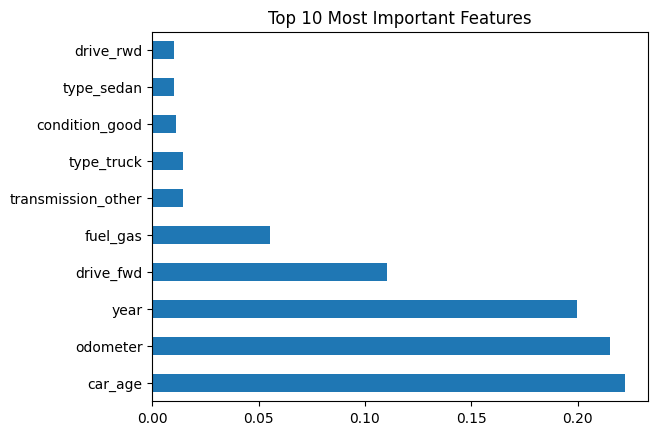

In [31]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind='barh')
plt.title("Top 10 Most Important Features")
plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
X_train_sample = X_train.sample(50000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

In [34]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, None],
}

In [35]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'n_estimators': [100, 150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [36]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': None, 'n_estimators': 150}


In [37]:
from sklearn.ensemble import GradientBoostingRegressor

best_model = GradientBoostingRegressor(
    n_estimators=300,   # 🔥 more trees (increase power)
    learning_rate=0.05, # 🔥 slower learning = better accuracy
    max_depth=6,        # 🔥 deeper trees
    random_state=42
)

best_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [38]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

print("Final MAE:", mae)

Final MAE: 3984.4772441164396


In [39]:
#import joblib
#joblib.dump(best_model, "car_price_model.pkl")
import joblib

joblib.dump(best_model, "car_price_model.pkl", compress=3)
joblib.dump(le_dict, "encoders.pkl", compress=3)
joblib.dump(X_train.columns.tolist(), "model_columns.pkl", compress=3)

['model_columns.pkl']

In [40]:
import os

print("Model size (MB):", os.path.getsize("car_price_model.pkl") / (1024*1024))

Model size (MB): 0.8170938491821289


### FEATURE IMPORTANCE


In [41]:
import pandas as pd

feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances)

year                       0.268544
car_age                    0.234306
odometer                   0.143177
drive_fwd                  0.136185
fuel_gas                   0.067682
                             ...   
manufacturer_land rover    0.000029
manufacturer_infiniti      0.000027
manufacturer_datsun        0.000023
manufacturer_alfa-romeo    0.000022
manufacturer_pontiac       0.000019
Length: 68, dtype: float64


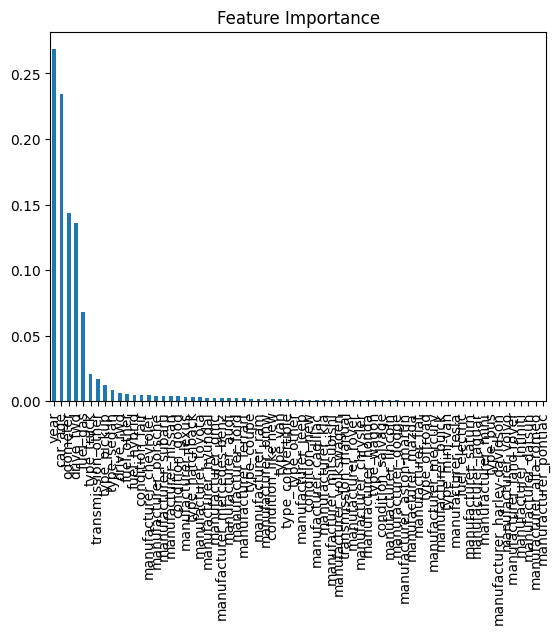

In [42]:
import matplotlib.pyplot as plt

feature_importances.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

In [43]:
def predict_price(year, odometer, manufacturer, fuel, transmission, drive, type_, condition):

    car_age = 2024 - year

    data = {
        "year":[year],
        "odometer":[odometer],
        "car_age":[car_age],
        "manufacturer":[manufacturer],
        "fuel":[fuel],
        "transmission":[transmission],
        "drive":[drive],
        "type":[type_],
        "condition":[condition]
    }

    df = pd.DataFrame(data)

    df = pd.get_dummies(df)

    df = df.reindex(columns=model_columns, fill_value=0)

    prediction = best_model.predict(df)

    return prediction[0]

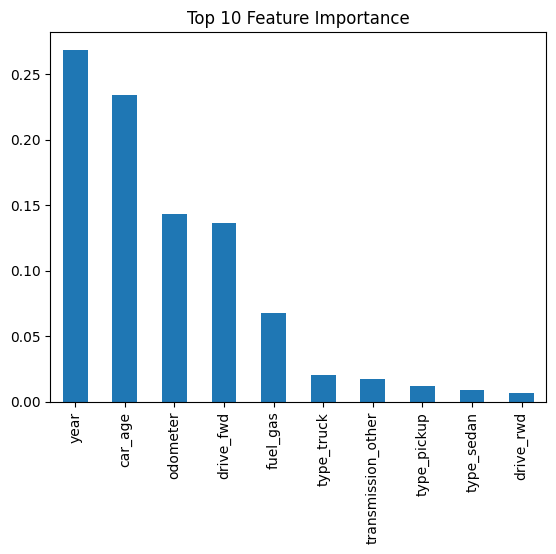

In [44]:
top_features = feature_importances.head(10)

top_features.plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Top 10 Feature Importance")
plt.show()

### Now that the features are clear and more defined, to say, car age determines price more than other features, followed by odometer which has to do with mileadge of the car. Now let us build a ## PREDICTION TOOL

def predict_price(year, odometer):
    
    car_age = 2024 - year
    
    # create dataframe with same columns as training data
    input_df = pd.DataFrame(columns=X_train.columns)
    
    # fill with zeros
    input_df.loc[0] = 0
    
    # set the values we know
    input_df["year"] = year
    input_df["odometer"] = odometer
    input_df["car_age"] = car_age
    
    prediction = best_model.predict(input_df)
    
    return prediction[0]

In [45]:
#predict_price(2018, 45000)

In [46]:
def predict_price(year, odometer,
                  manufacturer, condition, fuel,
                  transmission, drive, type_):

    car_age = 2024 - year

    input_df = pd.DataFrame(columns=model_columns)

    input_df.loc[0] = 0

    input_df["year"] = year
    input_df["odometer"] = odometer
    input_df["car_age"] = car_age

    if f"manufacturer_{manufacturer}" in input_df.columns:
        input_df[f"manufacturer_{manufacturer}"] = 1

    if f"condition_{condition}" in input_df.columns:
        input_df[f"condition_{condition}"] = 1

    if f"fuel_{fuel}" in input_df.columns:
        input_df[f"fuel_{fuel}"] = 1

    if f"transmission_{transmission}" in input_df.columns:
        input_df[f"transmission_{transmission}"] = 1

    if f"drive_{drive}" in input_df.columns:
        input_df[f"drive_{drive}"] = 1

    if f"type_{type_}" in input_df.columns:
        input_df[f"type_{type_}"] = 1

    prediction = best_model.predict(input_df)

    return round(float(prediction[0]), 2)

In [47]:
predict_price(
    2019,
    40000,
    "toyota",
    "good",
    "gas",
    "automatic",
    "fwd",
    "sedan"
)

21294.17

In [48]:
#year = int(input("Enter car year: "))
#odometer = int(input("Enter mileage: "))

#price = predict_price(year, odometer)

#print("Estimated Car Price: $", price)

### NOTE:
* The Prediction Model which predict how much a car can be bought for is done and dusted. We are 75% from finishing the product.

### 2. Profit Opportunity Detection Model

* Identifies vehicles that are likely to generate higher resale profit.

* The system compares predicted market price with listing price to detect undervalued cars.

* This helps dealerships know which cars to buy and resell.

#def detect_profit_opportunity(year, odometer, listing_price):

    #predicted_price = predict_price(year, odometer)

    #profit_margin = predicted_price - listing_price

    #if profit_margin > 5000:
        #rating = "🔥 GREAT DEAL"
    elif profit_margin > 2000:
        rating = "✅ GOOD DEAL"
    elif profit_margin > 0:
        rating = "⚖️ FAIR DEAL"
    else:
        rating = "❌ OVERPRICED"

    return {
        "predicted_price": predicted_price,
        "listing_price": listing_price,
        "profit_margin": round(profit_margin,2),
        "deal_rating": rating
    }

In [49]:
#detect_profit_opportunity(2019, 40000, 22000)

### NOTE:

* Now that we are done with Model 2, we need Model 3 to make the system even more powerfull, Model 2 can detect whether or not a car is a good deal or bad.

### 3. Fast-Selling Vehicle Prediction Model

* Predicts which cars are more likely to sell quickly.

* This helps dealerships prioritize inventory that will move faster and reduce storage costs.

In [50]:
df["posting_date"] = pd.to_datetime(df["posting_date"], utc=True)

In [51]:
df["posting_date"] = df["posting_date"].dt.tz_localize(None)

In [52]:
df["days_since_posted"] = (pd.Timestamp.now() - df["posting_date"]).dt.days

In [53]:
df[["posting_date","days_since_posted"]].head()

,posting_date,days_since_posted
27,2021-05-04 17:31:18,1795
28,2021-05-04 17:31:08,1795
29,2021-05-04 17:31:25,1795
30,2021-05-04 15:41:31,1795
31,2021-05-03 19:02:03,1796


In [54]:
def categorize_speed(days):

    if days <= 7:
        return "FAST"
    elif days <= 30:
        return "MEDIUM"
    else:
        return "SLOW"

df["sell_speed"] = df["days_since_posted"].apply(categorize_speed)

In [55]:
df["sell_speed"].value_counts()

sell_speed
SLOW    208404
Name: count, dtype: int64

### NOTE:
* Unfortunetly we have to rebuild Model 3 because it classified every case as slow, due to the command code instructed.

In [56]:
df["posting_date"].max()

Timestamp('2021-05-05 04:24:09')

In [57]:
reference_date = df["posting_date"].max()

df["days_since_posted"] = (reference_date - df["posting_date"]).dt.days

In [58]:
def categorize_speed(days):

    if days <= 3:
        return "FAST"
    elif days <= 10:
        return "MEDIUM"
    else:
        return "SLOW"

df["sell_speed"] = df["days_since_posted"].apply(categorize_speed)

In [59]:
df["sell_speed"].value_counts()

sell_speed
SLOW      89274
MEDIUM    63633
FAST      55497
Name: count, dtype: int64

## Train the Fast-Selling Prediction Model

In [60]:
# Create sell_speed feature based on price

df["sell_speed"] = "MEDIUM"

df.loc[df["price"] < df["price"].quantile(0.33), "sell_speed"] = "FAST"
df.loc[df["price"] > df["price"].quantile(0.66), "sell_speed"] = "SLOW"

print(df["sell_speed"].value_counts())

sell_speed
SLOW      70580
MEDIUM    69083
FAST      68741
Name: count, dtype: int64


In [61]:
# Required Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Features for Model 2
features_speed = [
    "year",
    "odometer",
    "car_age"
]

# Define X and y
X_speed = df[features_speed]
y_speed = df["sell_speed"]

# Train / Test Split
X_train_speed, X_test_speed, y_train_speed, y_test_speed = train_test_split(
    X_speed,
    y_speed,
    test_size=0.2,
    random_state=42
)

# Train Model
speed_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

speed_model.fit(X_train_speed, y_train_speed)

# Predictions
predictions = speed_model.predict(X_test_speed)

# Accuracy
accuracy = accuracy_score(y_test_speed, predictions)

print("Model 2 Accuracy:", accuracy)

Model 2 Accuracy: 0.7161056596530794


In [62]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_speed,
    y_speed,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.ensemble import GradientBoostingClassifier

speed_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

speed_model.fit(X_train_s, y_train_s)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Evaluate the Model

In [64]:
from sklearn.metrics import classification_report

speed_predictions = speed_model.predict(X_test_s)

print(classification_report(y_test_s, speed_predictions))

              precision    recall  f1-score   support

        FAST       0.70      0.76      0.73     13693
      MEDIUM       0.55      0.51      0.53     13998
        SLOW       0.75      0.74      0.75     13990

    accuracy                           0.67     41681
   macro avg       0.67      0.67      0.67     41681
weighted avg       0.67      0.67      0.67     41681



## Build the predict_sell_speed() Function

In [65]:
def predict_sell_speed(year, odometer):

    car_age = 2024 - year

    input_data = pd.DataFrame({
        "year": [year],
        "odometer": [odometer],
        "car_age": [car_age]
    })

    prediction = speed_model.predict(input_data)

    return prediction[0]

In [66]:
predict_sell_speed(2019, 40000)

'SLOW'

## Combine ALL 3 Models Into One AI System

In [67]:
def dealer_ai_analyzer(year, odometer, listing_price,
                       manufacturer, condition, fuel,
                       transmission, drive, type_):

    predicted_price = predict_price(
        year,
        odometer,
        manufacturer,
        condition,
        fuel,
        transmission,
        drive,
        type_
    )

    profit_margin = predicted_price - listing_price

    if profit_margin > 5000:
        deal_rating = "🔥 GREAT DEAL"
    elif profit_margin > 2000:
        deal_rating = "✅ GOOD DEAL"
    elif profit_margin > 0:
        deal_rating = "⚖️ FAIR DEAL"
    else:
        deal_rating = "❌ OVERPRICED"

    sell_speed = predict_sell_speed(year, odometer)

    result = {
        "Predicted Market Price": predicted_price,
        "Listing Price": listing_price,
        "Profit Margin": round(profit_margin, 2),
        "Deal Rating": deal_rating,
        "Expected Sell Speed": sell_speed
    }

    return result

In [68]:
dealer_ai_analyzer(
    2019,
    40000,
    22000,
    "toyota",
    "good",
    "gas",
    "automatic",
    "fwd",
    "sedan"
)

{'Predicted Market Price': 21294.17,
 'Listing Price': 22000,
 'Profit Margin': -705.83,
 'Deal Rating': '❌ OVERPRICED',
 'Expected Sell Speed': 'SLOW'}

In [69]:
import pickle

with open("sell_speed_model.pkl", "wb") as f:
    pickle.dump(speed_model, f)

In [70]:
!pip install streamlit


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
!pip install joblib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import joblib

#joblib.dump(model, "car_price_model.pkl")
joblib.dump(speed_model, "sell_speed_model.pkl")

['sell_speed_model.pkl']

## NOTE:

* The system is almost working. Although for accuracy, we have to retrain the models on reliable data that is South Africa market friendly, Kaggle data was good for setting knowledge base or rather intelligence base, therefore chnaces were high that it wasn't going to be able to cater for the SA dealers. Right now, datatset was scraped froem Auto Trader AI, which is an institution from South Africa with dataset fit for SA market. 

In [73]:
# Select useful columns
df = df[['price','year','manufacturer','condition','fuel','odometer','transmission','drive','type']]

# Remove missing values
df = df.dropna()

# Remove unrealistic prices
df = df[(df['price'] > 1000) & (df['price'] < 100000)]

# Remove unrealistic odometer values
df = df[(df['odometer'] > 100) & (df['odometer'] < 500000)]

# Create car age feature
df["car_age"] = 2024 - df["year"]

df.head()

,price,year,manufacturer,condition,fuel,odometer,transmission,drive,type,car_age
27,33590,2014,gmc,good,gas,57923.0,other,4wd,pickup,10
28,22590,2010,chevrolet,good,gas,71229.0,other,4wd,pickup,14
29,39590,2020,chevrolet,good,gas,19160.0,other,4wd,pickup,4
30,30990,2017,toyota,good,gas,41124.0,other,4wd,pickup,7
31,15000,2013,ford,excellent,gas,128000.0,automatic,rwd,truck,11


In [74]:
features = [
    'year',
    'odometer',
    'car_age',
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type'
]

X = df[features]
y = df['price']

In [75]:
X = pd.get_dummies(X)

# Train The Model

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [77]:
from sklearn.ensemble import GradientBoostingRegressor

best_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

best_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [78]:
from sklearn.metrics import mean_absolute_error

preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("Model 3 MAE:", mae)

Model 3 MAE: 3837.2997016519375


In [79]:
import joblib

joblib.dump(best_model, "car_price_model.pkl")

print("Model saved successfully")

Model saved successfully


# Model 2 Correct Code and Function

In [80]:
def predict_price(year, odometer, manufacturer, condition, fuel, transmission, drive, type):

    car_age = 2024 - year

    input_df = pd.DataFrame({
        "year":[year],
        "odometer":[odometer],
        "car_age":[car_age],
        "manufacturer":[manufacturer],
        "condition":[condition],
        "fuel":[fuel],
        "transmission":[transmission],
        "drive":[drive],
        "type":[type]
    })

    input_df = pd.get_dummies(input_df)

    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)

    prediction = best_model.predict(input_df)

    return round(float(prediction[0]),2)

In [81]:
price = predict_price(
    year=2020,
    odometer=40000,
    manufacturer="toyota",
    condition="good",
    fuel="gas",
    transmission="automatic",
    drive="fwd",
    type="sedan"
)

print("Predicted Price:", price)

Predicted Price: 21520.11


In [82]:
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [83]:
import joblib

joblib.dump(speed_model, "speed_model.pkl", compress=3)

print("✅ Speed model saved (compressed)")

✅ Speed model saved (compressed)


### We have a big problem here. The problem is that the model cant ak ethe difference between brands and models, so it then tends to use odometer and car age to determine price which is very bad. So we dont have a choice but to retrain the models.

## DealerNexusAI Progress Update:

### Weaknesses:
1. It only has a limited number of cars in the Analyzeer page, hence it is importnat that we make sure it's not limited to any brand, rather the user just types the brand they want. Also it has limited models like SUV, sedan, pick up..ofwhich they rae plenty of models. Rather its either it includes all or user gets to type or fill for themselves.
2. Still in the Analyzer page, the price and miliedge buttons can be confusing, so we have to label the buttons, so that its easy for the user. Do'nt change the UI/UX just add whats missing, dont edit what's already good. 